# Wine Quality: package-executed SHAP-IMV example

This notebook **executes `imv.BinaryIMV`** and creates its plot from the values computed below. It does not load a result pickle.

For an interactive example, it uses five documented features, three folds, Logistic Regression, and a deterministic sample where needed. This is deliberately labelled a package demonstration; it is not substituted for the full paper configuration. Full-reproduction discrepancies and exact Titanic parity are documented in [`../../documentation/PARITY_RESULTS.md`](../../documentation/PARITY_RESULTS.md).

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from imv import BinaryIMV

HERE = Path.cwd()
DATA = HERE.parent / "data"
FIGURES = HERE / "figures"
FIGURES.mkdir(exist_ok=True)

/Users/valler/miniforge3/envs/imv/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
data = pd.read_csv(DATA / "wine_quality_processed.csv")
data = data.sample(n=5000, random_state=42).reset_index(drop=True)
features = ['volatile_acidity', 'citric_acid', 'chlorides', 'sulphates', 'alcohol']
data[features + ["target"]].head()

,volatile_acidity,citric_acid,chlorides,sulphates,alcohol,target
0,0.17,0.74,0.045,0.38,12.2,1
1,0.64,0.21,0.077,0.45,9.9,0
2,0.39,0.34,0.020,0.44,12.0,1
3,0.28,0.47,0.040,0.51,9.5,1
4,0.35,0.20,0.054,0.50,8.9,1


In [3]:
evaluator = BinaryIMV(
    data=data,
    outcome_variable="target",
    optional_explanatory_variables=features,
    model_creator=lambda: LogisticRegression(max_iter=1000, random_state=42),
    split_method="kfold",  # original notebook split semantics
    n_splits=3,
    prop_test=0.2,
    model_type="classification",
    random_seed=42,
    n_jobs=1,
    verbose=False,
)
coalition_results = evaluator.run_evaluation()
shap_imv = pd.Series(
    {feature: evaluator.calculate_imvshapley_value(feature) for feature in features},
    name="SHAP-IMV",
).sort_values(ascending=False)
shap_imv.to_frame()

  0%|          | 0/32 [00:00<?, ?it/s]

,SHAP-IMV
alcohol,0.146
volatile_acidity,0.058
chlorides,0.014
sulphates,0.006
citric_acid,0.002


/Users/valler/Python/imv_ml_package/src/imv/shap_imv/evaluator.py:465: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)
/Users/valler/Python/imv_ml_package/src/imv/shap_imv/evaluator.py:465: UserWarning: Numpy array is not a supported type for `palette`. Please convert your palette to a list. This will become an error in v0.14
  sns.barplot(x=sorted_values, y=sorted_keys, palette=colors, orient='h', ax=ax)


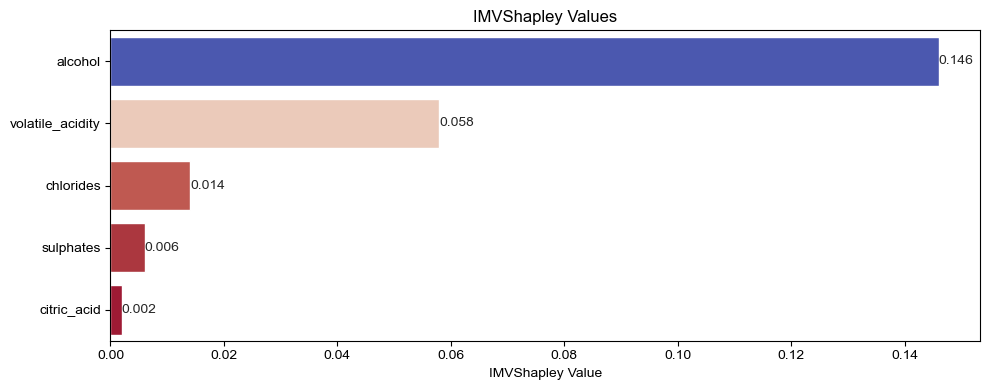

PosixPath('/Users/valler/Python/imv_ml_package/examples/shap_imv/figures/shap_imv_winequality_package_demo.png')

In [4]:
fig, ax = evaluator.evaluate_imvshapley(figsize=(10, 4))
fig.tight_layout()
figure_path = FIGURES / "shap_imv_winequality_package_demo.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()
figure_path